# YOLO Apply

This notebook runs YOLO inference directly through `run_detection()`.

In [3]:
from pathlib import Path
from types import SimpleNamespace
import csv
import sys

from IPython.display import display
from PIL import Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from yolo_apply import run_detection

In [4]:
MAX_IMAGES = None  # Set to None to run all preprocessed images.

args = SimpleNamespace(
    preprocessing_summary_csv=config.PREPROCESSING_SUMMARY_CSV,
    model_path=config.YOLO_MODEL_PATH,
    output_csv=config.YOLO_DETECTIONS_CSV,
    annotated_dir=config.YOLO_ANNOTATED_DIR,
    conf=0.25,
    max_images=MAX_IMAGES,
)
args

namespace(preprocessing_summary_csv=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/preprocessing_summary.csv'),
          model_path=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/models/pck_yolo_best.pt'),
          output_csv=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/yolo/detections.csv'),
          annotated_dir=PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/yolo/annotated_images'),
          conf=0.25,
          max_images=None)

In [5]:
detection_rows = run_detection(args)
len(detection_rows), detection_rows[:2]

YOLO apply: 100%|██████████| 9119/9119 [10:36<00:00, 14.33image/s]


(77343,
 [{'index': '1',
   'image_name': 'IR_57327.jpg',
   'source_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/thermal_images/IR_57327.jpg',
   'preprocessed_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/images/IR_57327.png',
   'temperature_map_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/temperature_maps/IR_57327.npy',
   'scale_top': '34.0',
   'scale_bottom': '19.5',
   'scale_source': 'digit_classifier',
   'scale_ocr_score': '0.0',
   'normalize_min': '18.0',
   'normalize_max': '50.0',
   'width': '640',
   'height': '640',
   'annotated_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/yolo/annotated_images/IR_57327_pred.jpg',
   'detection_index': 1,
   'label': 'Person',
   'confidence': '0.874230',
   'bbox_x0': '387.652466',
   'bbox_y0': '222.652374',
   'bbox_x1': '577.045776',
   'bbox_y1': '487.564484'},
  {

detections with labels: 77343


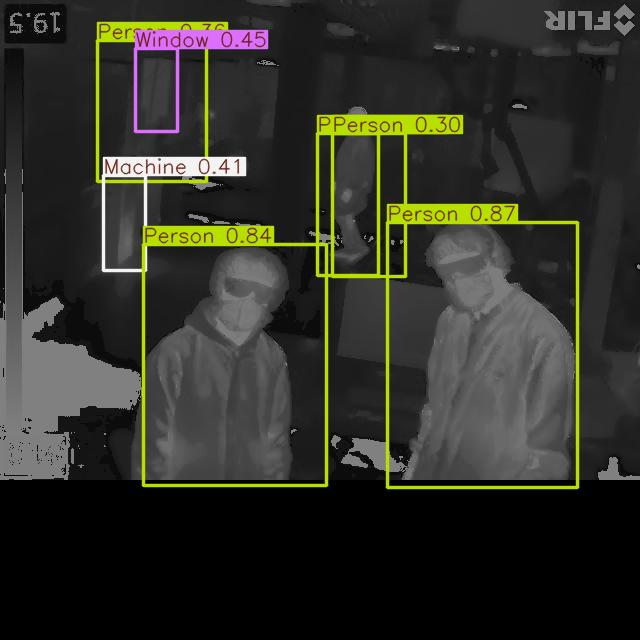

In [6]:
kept = [row for row in detection_rows if row.get('label')]
print('detections with labels:', len(kept))
if detection_rows:
    display(Image.open(detection_rows[0]['annotated_image_path']))